In [1]:
import sys
from pyprojroot import here

# Ritorna il percorso assoluto della root del progetto
PROJECT_ROOT = str(here()) + "/"
sys.path.append(PROJECT_ROOT)
sys.dont_write_bytecode = True

print(f"La root del progetto è: {PROJECT_ROOT}")

La root del progetto è: /home/cvalentino/SissaUnisaDraftCodes/


In [2]:
from paths import DRT_PATH, TP4_PATH, MODEL_PATH, ROCK_PATH

ABS_PATH = PROJECT_ROOT + DRT_PATH + TP4_PATH
LOAD_MODEL = PROJECT_ROOT + MODEL_PATH + ROCK_PATH

model_name = "Rock1.blend"

Import delle librerie

In [3]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from modelaquisition.bl2pina import Blend2Pina
from modelaquisition.bl2msh import Blend2Mesh
from modelaquisition.msh2xdmf import Msh2Xdmf

Fissiamo precisione doppia

In [4]:
torch.set_default_dtype(torch.float64)
seed = 42
torch.manual_seed(seed)

# Data Generation

In questo notebook andiamo a generare i dati campionati tramite sensori circa la temperatura superficiale dell'artefatto.
Tali dati permetteranno di definire le condizioni al contorno del modello che analizzeremo tramite Physics-Informed Neural Networks.
Tra le assunzioni necessarie all'esperimento richiederemo che:

*   La temperatura sia uniforme intorno all'artefatto e che si modifichi con continuità nel tempo

*   L'artefatto è composto da un unico materiale e la variazione di temperatura interna sia un fenomeno continuo

L'obiettivo è di definire un problema ben posto secondo Hadamard (la soluzione esiste, è unica, e dipende con continuità dai dati).

Inizialmente effettuiamo gli imput necessari e fissiamo il seme del generatore per garantire la riproducibilità.

## Fissiamo le temperature di giornata

In [5]:
number_samples = 101
mean_temperature = 22.4
std_temperature = 1.2

temperature = torch.normal(
    mean=torch.full((number_samples,), mean_temperature),
    std=torch.full((number_samples,), std_temperature)
)

In [6]:
# Calcola gli indici per i valori fuori 2 deviazioni standard
over_std_idx = (torch.abs(temperature - mean_temperature) - 2 * std_temperature >= 0) & (temperature - mean_temperature >= 0)
under_std_idx = (torch.abs(temperature - mean_temperature) - 2 * std_temperature >= 0) & (temperature - mean_temperature <= 0)

# Modifica i valori che superano ±2 deviazioni standard
temperature[over_std_idx] = mean_temperature + 2 * std_temperature
temperature[under_std_idx] = mean_temperature - 2 * std_temperature

In [7]:
# Dividi in due parti
half = number_samples // 2  # Divisione intera
first_part = temperature[:half].clone()  # Cloniamo per evitare modifiche in-place indesiderate
second_part = temperature[half:].clone()

# Ordina la prima metà in ordine crescente
first_part, _ = torch.sort(first_part)

# Ordina la seconda metà in ordine decrescente
second_part, _ = torch.sort(second_part, descending=True)

# Concatena le due parti
temperature = torch.cat([first_part, second_part])

In [8]:
date_range = pd.date_range(start='2024-01-01 00:00:00', end='2024-01-01 23:59:00', periods=number_samples)
temperature_data = pd.DataFrame({'Datetime': date_range, 'Temperature_C': temperature.detach().numpy()})

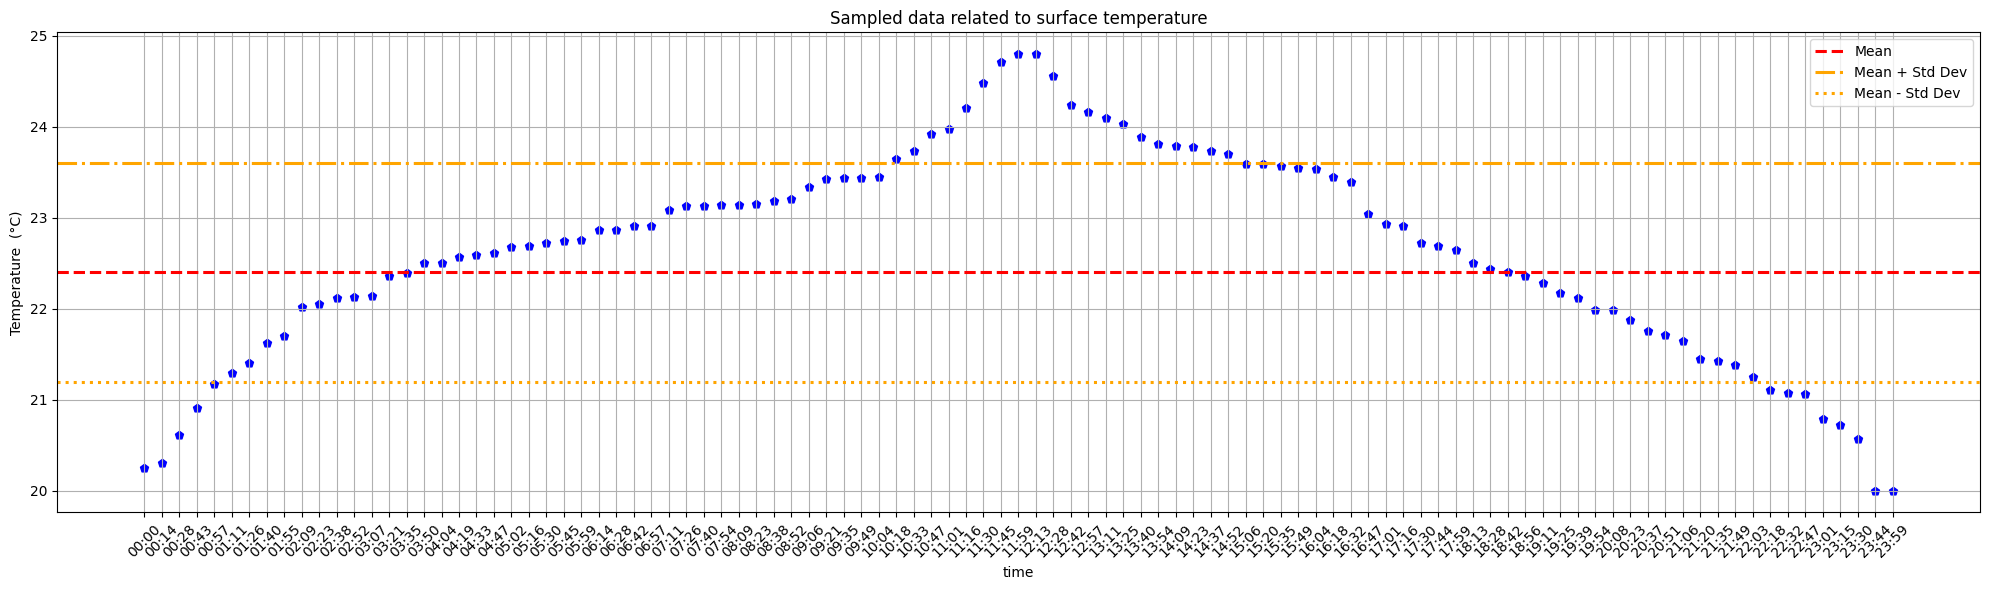

In [9]:
mean_plus_std = mean_temperature + std_temperature
mean_minus_std = mean_temperature - std_temperature

plt.figure(figsize=(20, 6))
plt.scatter(temperature_data['Datetime'], temperature_data['Temperature_C'], color='blue', marker="p")
plt.axhline(mean_temperature, color='red', linestyle='--', label='Mean', linewidth=2.2)
plt.axhline(mean_plus_std, color='orange', linestyle='-.', label='Mean + Std Dev', linewidth=2.2)
plt.axhline(mean_minus_std, color='orange', linestyle=':', label='Mean - Std Dev', linewidth=2.2)
plt.legend()
plt.title("Sampled data related to surface temperature")
plt.xlabel("time")
plt.ylabel("Temperature  (°C)")
plt.grid(True)
plt.xticks(temperature_data['Datetime'], temperature_data['Datetime'].dt.strftime('%H:%M'), rotation=45)
plt.tight_layout()
plt.show()

In [10]:
temperature_data.to_csv("files/TempData.csv", sep=";", index=False)

## Campionamento al contorno

Fissiamo i punti in cui sono installati i sensori

In [11]:
rock = Blend2Pina(LOAD_MODEL + model_name)

Read blend: "/home/cvalentino/SissaUnisaDraftCodes/models/rock/Rock1.blend"


Acquisizione dei punti al contrno

In [12]:
num_points = 100

surface = rock.boundary()
points = surface.sample(num_points)

In [13]:
T_initial = torch.tensor(temperature_data["Temperature_C"][0], dtype = torch.float64)
data_boundary = torch.tensor(temperature_data["Temperature_C"], dtype = torch.float64).reshape((temperature_data["Temperature_C"].shape[0], 1))

In [14]:
T_initial = torch.reshape(T_initial, (1, 1))
df_initial_value = pd.DataFrame(
    T_initial.detach().numpy(),
    columns=['u']
)

df_initial_value.to_csv("./files/initial.csv", sep=";")

In [15]:
LT_lst = list()
time = torch.linspace(0, 1, data_boundary.shape[0])
T_boundary = list()

for i in range(1, time.shape[0]):
  for sp_el in points:
    LT_lst.append([sp_el.tensor[0].item(), sp_el.tensor[1].item(), sp_el.tensor[2].item(), time[i]])
    T_boundary.append([temperature_data["Temperature_C"][i]])

LT_lst = torch.tensor(LT_lst)
T_boundary = torch.tensor(T_boundary)

In [16]:
boundary = torch.cat([LT_lst, T_boundary], axis=-1)
df_boundary = pd.DataFrame(
    boundary.detach().numpy(),
    columns = ['x', 'y', 'z', 't', 'u']
)

df_boundary.to_csv("./files/data.csv", sep=";")

## Creazione mesh e xdmf

In [17]:
rock_msh = Blend2Mesh(LOAD_MODEL + model_name, "rock")

Read blend: "/home/cvalentino/SissaUnisaDraftCodes/models/rock/Rock1.blend"


In [18]:
rock_msh.create_mesh(len_msh=0.07)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 7 (Line)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 10%] Meshing curve 9 (Line)
Info    : [ 10%] Meshing curve 10 (Line)
Info    : [ 10%] Meshing curve 11 (Line)
Info    : [ 10%] Meshing curve 12 (Line)
Info    : [ 10%] Meshing curve 13 (Line)
Info    : [ 10%] Meshing curve 14 (Line)
Info    : [ 10%] Meshing curve 15 (Line)
Info    : [ 10%] Meshing curve 16 (Line)
Info    : [ 10%] Meshing curve 17 (Line)
Info    : [ 10%] Meshing curve 18 (Line)
Info    : [ 10%] Meshing curve 19 (Line)
Info    : [ 10%] Meshing curve 20 (Line)
Info    : [ 10%] Meshing curve 21 (Line)
Info    : [ 10%] Meshing curve 22 (Line)
Info    : [ 10%] Meshing curve 23 (Line)
Info    : [ 10%] Meshing curve 24 (Line)
I

In [19]:
rock_xdmf = Msh2Xdmf("rock.msh", "rock")
rock_xdmf.to_xdmf()

Info    : Reading 'rock.msh'...
Info    : 867 entities
Info    : 42343 nodes
Info    : 263548 elements
Info    : Done reading 'rock.msh'                                          
Info    : Meshing 1D...
Info    : Done meshing 1D (Wall 0.000143287s, CPU 0.000143s)
Info    : Meshing 2D...
Info    : Done meshing 2D (Wall 9.85991e-05s, CPU 9.5e-05s)
Info    : Meshing 3D...
Info    : Done meshing 3D (Wall 0.419194s, CPU 0.419636s)
Info    : Optimizing mesh...
Info    : Done optimizing mesh (Wall 0.014915s, CPU 0.015154s)
Info    : 42343 nodes 263548 elements


In [20]:
rock_msh.export_vertices("rock.msh", "./files/mesh_points")

Info    : Reading 'rock.msh'...
Info    : 867 entities
Info    : 42343 nodes
Info    : 263548 elements
Info    : Done reading 'rock.msh'                                          


/home/cvalentino/SissaUnisaDraftCodes/modelaquisition/bl2msh.py:301: FutureWarning: Starting with pandas version 3.0 all arguments of to_csv except for the argument 'path_or_buf' will be keyword-only.
  df.to_csv(filename + ".csv", sep, index=False)
